# PTB-XL Preprocessing

This notebook creates the final Lead II ECG datasets for the conditional ECG generation baseline. It repeats the filtering decisions from the exploratory notebook so the preprocessing is reproducible.

**Output:** `train.npz`, `validation.npz`, `test.npz`, and `label_mapping.json`.


## 1. Setup

Set the dataset and output paths before running the notebook. The expected PTB-XL folder contains `ptbxl_database.csv`, `scp_statements.csv`, and `records100/`.


In [ ]:
from pathlib import Path
from tqdm.auto import tqdm
from collections import Counter
from __future__ import annotations

import ast
import json
import wfdb

import numpy as np
import pandas as pd
import neurokit2 as nk
import matplotlib.pyplot as plt

RANDOM_STATE = 42
SAMPLING_RATE = 100
RECORDING_SAMPLES = 10 * SAMPLING_RATE
SEGMENT_SAMPLES = 5 * SAMPLING_RATE
MIN_CLASS_SIZE = 300
TARGET_NORM = 4050

# Update this path if PTB-XL is stored elsewhere.
DATASET_PATH = Path("../physionet.org/files/ptb-xl/1.0.3")
OUTPUT_PATH = Path("../processed_data")
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

assert DATASET_PATH.exists(), f"Dataset folder not found: {DATASET_PATH.resolve()}"
assert (DATASET_PATH / "ptbxl_database.csv").exists(), "ptbxl_database.csv is missing"
assert (DATASET_PATH / "scp_statements.csv").exists(), "scp_statements.csv is missing"


## 2. Helper functions

The functions below keep the filtering, label mapping, and waveform loading steps consistent and easy to check.


In [5]:
NOISE_COLUMNS = ["baseline_drift", "static_noise", "burst_noise"]


def parse_scp_codes(value: str) -> dict:
    '''Convert the SCP-code string in the metadata into a dictionary.'''
    return ast.literal_eval(value)


def has_lead_ii(value: object) -> bool:
    '''Return True only when a PTB-XL quality field explicitly lists Lead II.'''
    if pd.isna(value):
        return False
    leads = [item.strip() for item in str(value).split(",") if item.strip()]
    return "II" in leads


def get_superclasses(scp_codes: dict, diagnostic_map: dict[str, str]) -> list[str]:
    '''Map raw SCP codes to sorted PTB-XL diagnostic superclasses.'''
    return sorted({diagnostic_map[code] for code in scp_codes if code in diagnostic_map})


def combination_name(superclasses: list[str]) -> str:
    '''Use one readable categorical label for a single diagnosis or common pair.'''
    return "+".join(superclasses)


def load_lead_ii(record_path: Path) -> np.ndarray:
    '''Load and validate the original 10-second Lead II signal.'''
    signal, fields = wfdb.rdsamp(str(record_path))
    assert "II" in fields["sig_name"], f"Lead II is missing from {record_path}"

    lead_ii = signal[:, fields["sig_name"].index("II")].astype(np.float32)
    assert lead_ii.shape == (RECORDING_SAMPLES,), (
        f"Expected {RECORDING_SAMPLES} samples, got {lead_ii.shape} for {record_path}"
    )

    assert np.isfinite(lead_ii).all(), f"Invalid values found in {record_path}"
    return lead_ii


def clean_ecg_signal(signal: np.ndarray) -> np.ndarray:
    '''Clean one Lead II ECG signal using NeuroKit.'''
    cleaned = nk.ecg_clean(
        signal,
        sampling_rate=SAMPLING_RATE,
        method="neurokit",
    )

    cleaned = np.asarray(cleaned, dtype=np.float32)

    assert cleaned.shape == (RECORDING_SAMPLES,)
    assert np.isfinite(cleaned).all(), "Cleaning produced invalid values"
    return cleaned


def class_count_table(frame: pd.DataFrame, label_col: str = "class_name") -> pd.DataFrame:
    '''Return a readable class-count table.'''
    return (
        frame[label_col]
        .value_counts()
        .rename_axis("Class")
        .reset_index(name="Count")
        .assign(Percentage=lambda x: (100 * x["Count"] / x["Count"].sum()).round(2))
    )


## 3. Load metadata and map diagnostic labels

PTB-XL contains many raw SCP statements. Only diagnostic statements are mapped to the five diagnostic superclasses used in this project.


In [6]:
metadata = pd.read_csv(DATASET_PATH / "ptbxl_database.csv")

# In the PTB-XL reference file, the SCP code is stored as the first column.
scp_statements = pd.read_csv(DATASET_PATH / "scp_statements.csv", index_col=0)
scp_statements.index.name = "scp_code"

diagnostic_statements = scp_statements[scp_statements["diagnostic"] == 1].copy()
diagnostic_map = diagnostic_statements["diagnostic_class"].to_dict()

assert set(diagnostic_map.values()) == {"NORM", "MI", "STTC", "CD", "HYP"}

metadata["scp_codes"] = metadata["scp_codes"].map(parse_scp_codes)
metadata["superclasses"] = metadata["scp_codes"].map(
    lambda codes: get_superclasses(codes, diagnostic_map)
)

print(f"Raw records: {len(metadata):,}")
display(metadata[["ecg_id", "scp_codes", "superclasses", "strat_fold"]].head())


Raw records: 21,799


,ecg_id,scp_codes,superclasses,strat_fold
0,1,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",[NORM],3
1,2,"{'NORM': 80.0, 'SBRAD': 0.0}",[NORM],2
2,3,"{'NORM': 100.0, 'SR': 0.0}",[NORM],5
3,4,"{'NORM': 100.0, 'SR': 0.0}",[NORM],3
4,5,"{'NORM': 100.0, 'SR': 0.0}",[NORM],4


## 4. Apply the baseline dataset filters

The filtering below follows the design decisions made in the EDA notebook. Counts are printed after each step so the effect of every decision is visible.


In [7]:
def report_filter(step: str, before: int, after: int) -> None:
    removed = before - after
    print(f"{step}: removed {removed:,} ({removed / before * 100:.2f}%), remaining {after:,}")


# 1. Remove records without a diagnostic superclass.
before = len(metadata)
metadata = metadata[metadata["superclasses"].str.len() > 0].copy()
report_filter("No diagnostic superclass", before, len(metadata))

# 2. Remove records whose Lead II is marked with baseline drift, static noise, or burst noise.
before = len(metadata)
lead_ii_noise = metadata[NOISE_COLUMNS].apply(
    lambda row: any(has_lead_ii(value) for value in row), axis=1
)
metadata = metadata.loc[~lead_ii_noise].copy()
report_filter("Lead II quality noise", before, len(metadata))

# 3. Keep one-label and two-label records only.
before = len(metadata)
metadata = metadata[metadata["superclasses"].str.len() <= 2].copy()
report_filter("More than two diagnostic labels", before, len(metadata))

# Each remaining diagnostic combination is one categorical class for the baseline.
metadata["class_name"] = metadata["superclasses"].map(combination_name)

# 4. Remove classes with fewer than MIN_CLASS_SIZE records.
before = len(metadata)
counts_before_threshold = metadata["class_name"].value_counts()
valid_classes = counts_before_threshold[counts_before_threshold >= MIN_CLASS_SIZE].index
metadata = metadata[metadata["class_name"].isin(valid_classes)].copy()
report_filter(f"Classes with fewer than {MIN_CLASS_SIZE} records", before, len(metadata))

# 5. Randomly downsample only pure NORM. All other classes are retained.
norm_mask = metadata["class_name"].eq("NORM")
norm_records = metadata.loc[norm_mask]
other_records = metadata.loc[~norm_mask]
assert len(norm_records) >= TARGET_NORM, "TARGET_NORM is larger than the available NORM class"

norm_records = norm_records.sample(n=TARGET_NORM, random_state=RANDOM_STATE)
metadata = pd.concat([norm_records, other_records], ignore_index=True)
metadata = metadata.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

assert metadata["class_name"].eq("NORM").sum() == TARGET_NORM
assert metadata["superclasses"].str.len().isin([1, 2]).all()
assert (~metadata[NOISE_COLUMNS].apply(lambda row: any(has_lead_ii(v) for v in row), axis=1)).all()

print("\nFinal record-level class distribution")
display(class_count_table(metadata))
print(f"Final records before segmentation: {len(metadata):,}")


No diagnostic superclass: removed 411 (1.89%), remaining 21,388
Lead II quality noise: removed 168 (0.79%), remaining 21,220
More than two diagnostic labels: removed 1,070 (5.04%), remaining 20,150
Classes with fewer than 300 records: removed 212 (1.05%), remaining 19,938

Final record-level class distribution


,Class,Count,Percentage
0,NORM,4050,27.00
1,MI,2513,16.75
2,STTC,2384,15.89
3,CD,1693,11.29
4,CD+MI,1284,8.56
5,HYP+STTC,776,5.17
6,MI+STTC,594,3.96
7,HYP,533,3.55
8,CD+STTC,467,3.11
9,CD+NORM,406,2.71


Final records before segmentation: 15,000


## 5. Create integer labels

Single diagnoses and common two-diagnosis combinations are treated as separate classes. The same mapping is saved with the processed datasets.


In [8]:
class_names = sorted(metadata["class_name"].unique())
NUM_CLASSES = len(class_names)

label_to_id = {name: index for index, name in enumerate(class_names)}
id_to_label = {str(index): name for name, index in label_to_id.items()}

metadata["label"] = metadata["class_name"].map(label_to_id).astype(np.int64)

assert metadata["label"].notna().all()
assert metadata["label"].nunique() == NUM_CLASSES

print("Label mapping:")
for label_id, name in id_to_label.items():
    print(f"{label_id}: {name}")


Label mapping:
0: CD
1: CD+HYP
2: CD+MI
3: CD+NORM
4: CD+STTC
5: HYP
6: HYP+STTC
7: MI
8: MI+STTC
9: NORM
10: STTC


## 6. Load, validate, and clean Lead II

Low-resolution PTB-XL recordings are loaded from `filename_lr`. Only Lead II is kept. Every recording is checked for the expected length and finite values before and after `neurokit2.ecg_clean()`.

This is the longest step in the notebook.


Cleaning Lead II ECGs: 100%|██████████| 15000/15000 [00:36<00:00, 408.27it/s]


Successfully cleaned 15,000 Lead II recordings.


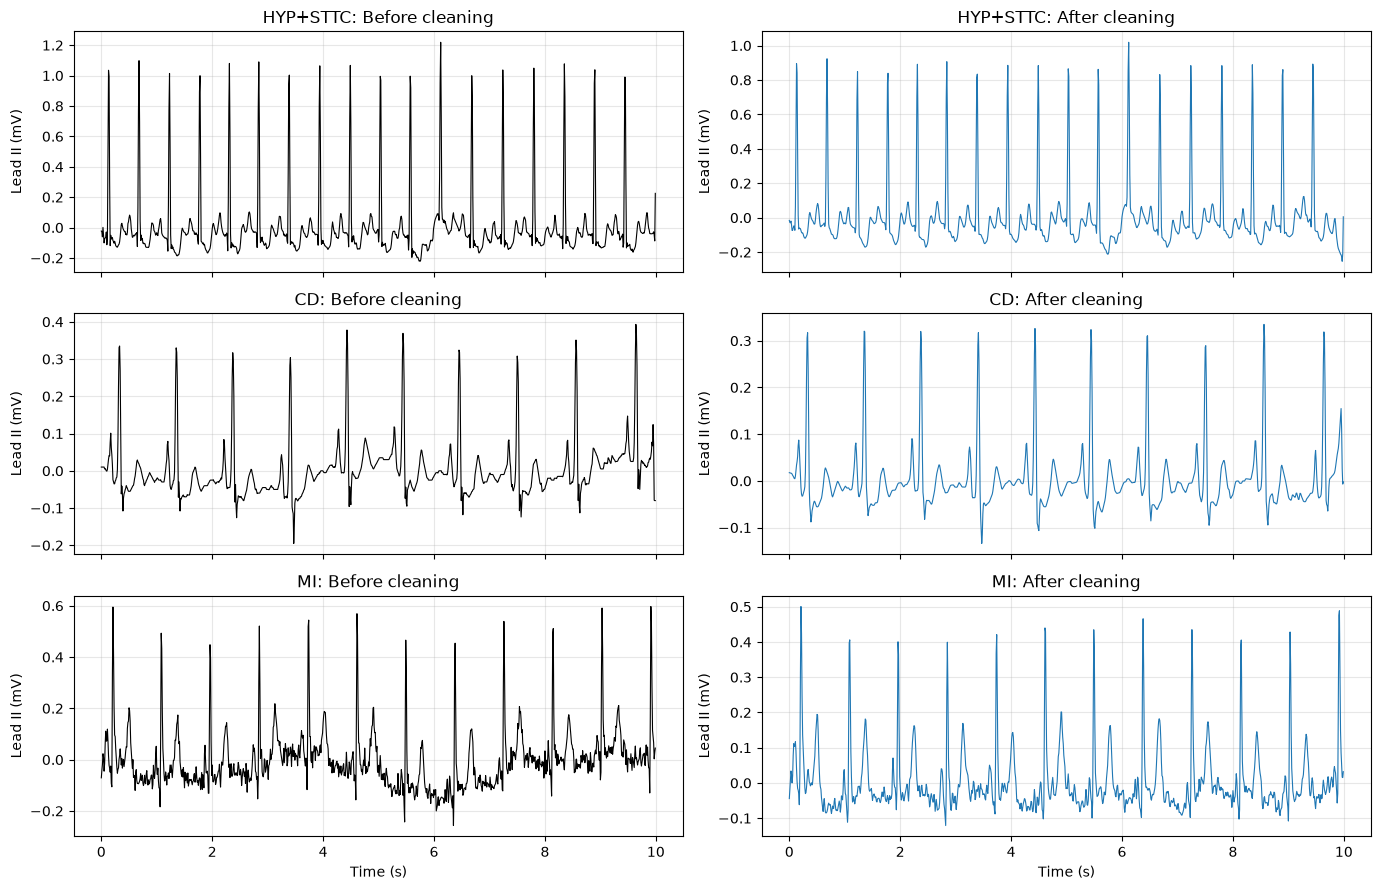

In [9]:
records = []
failed_records = []

# Select three diagnostic classes to show before/after cleaning.
example_classes = metadata["class_name"].drop_duplicates().head(3).tolist()
cleaning_examples = {}

for row in tqdm(
    metadata.itertuples(index=False),
    total=len(metadata),
    desc="Cleaning Lead II ECGs",
):
    record_path = DATASET_PATH / row.filename_lr

    try:
        raw_signal = load_lead_ii(record_path)
        cleaned_signal = clean_ecg_signal(raw_signal)

        records.append(
            {
                "signal": cleaned_signal,
                "label": row.label,
                "class_name": row.class_name,
                "fold": row.strat_fold,
                "ecg_id": row.ecg_id,
                "patient_id": row.patient_id,
            }
        )

        if (
            row.class_name in example_classes
            and row.class_name not in cleaning_examples
        ):
            cleaning_examples[row.class_name] = {
                "raw": raw_signal,
                "cleaned": cleaned_signal,
            }

    except Exception as error:
        failed_records.append(
            {
                "ecg_id": row.ecg_id,
                "path": str(record_path),
                "error": str(error),
            }
        )

if failed_records:
    failures = pd.DataFrame(failed_records)
    display(failures)

    failed_ids = set(failures["ecg_id"])
    metadata = (
        metadata[~metadata["ecg_id"].isin(failed_ids)]
        .reset_index(drop=True)
    )

    print(f"Excluded {len(failed_ids)} ECG record(s) with unavailable waveform files.")

assert len(records) == len(metadata)
print(f"Successfully cleaned {len(records):,} Lead II recordings.")

# Plot original and cleaned examples.
time = np.arange(RECORDING_SAMPLES) / SAMPLING_RATE

fig, axes = plt.subplots(
    len(cleaning_examples),
    2,
    figsize=(14, 3 * len(cleaning_examples)),
    sharex=True,
)

if len(cleaning_examples) == 1:
    axes = np.array([axes])

for row_index, (class_name, example) in enumerate(cleaning_examples.items()):
    axes[row_index, 0].plot(time, example["raw"], color="black", linewidth=0.8)
    axes[row_index, 0].set_title(f"{class_name}: Before cleaning")
    axes[row_index, 0].set_ylabel("Lead II (mV)")
    axes[row_index, 0].grid(True, alpha=0.3)

    axes[row_index, 1].plot(
        time,
        example["cleaned"],
        color="tab:blue",
        linewidth=0.8,
    )
    axes[row_index, 1].set_title(f"{class_name}: After cleaning")
    axes[row_index, 1].set_ylabel("Lead II (mV)")
    axes[row_index, 1].grid(True, alpha=0.3)

axes[-1, 0].set_xlabel("Time (s)")
axes[-1, 1].set_xlabel("Time (s)")

plt.tight_layout()
plt.savefig(
    OUTPUT_PATH / "lead_ii_before_after_cleaning.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

## 7. Segment each recording into two five-second clips

Each 10-second ECG is split into a first and second 5-second segment. Both segments keep the same class label, fold, ECG ID, and patient ID. This keeps all segments from an ECG in the same final split.


In [10]:
segments = []

for record in records:
    signal = record["signal"]
    first_half = signal[:SEGMENT_SAMPLES]
    second_half = signal[SEGMENT_SAMPLES:]
    assert first_half.shape == (SEGMENT_SAMPLES,)
    assert second_half.shape == (SEGMENT_SAMPLES,)

    for segment_index, segment in enumerate((first_half, second_half)):
        segments.append(
            {
                **{key: value for key, value in record.items() if key != "signal"},
                "segment": segment,
                "segment_index": segment_index,
            }
        )

assert len(segments) == 2 * len(records)
print(f"Records before segmentation: {len(records):,}")
print(f"Five-second segments: {len(segments):,}")


Records before segmentation: 15,000
Five-second segments: 30,000


## 8. Split by official PTB-XL folds

Folds 1–8 are used for training, fold 9 for validation, and fold 10 for testing. The split is applied using the original ECG fold, so no two segments from the same recording can appear in different splits.


In [11]:
def build_split(segment_rows: list[dict], split_name: str) -> dict[str, np.ndarray]:
    """Convert ECG segments into arrays for one dataset split."""
    assert segment_rows, f"{split_name} split is empty"

    label_ids = np.asarray(
        [row["label"] for row in segment_rows],
        dtype=np.int64,
    )

    labels_onehot = np.eye(
        NUM_CLASSES,
        dtype=np.float32,
    )[label_ids]

    return {
        "signals": np.stack(
            [row["segment"] for row in segment_rows]
        ).astype(np.float32),
        "labels": label_ids,
        "labels_onehot": labels_onehot,
        "ecg_ids": np.asarray([row["ecg_id"] for row in segment_rows]),
        "patient_ids": np.asarray([row["patient_id"] for row in segment_rows]),
        "folds": np.asarray(
            [row["fold"] for row in segment_rows],
            dtype=np.int64,
        ),
        "segment_indices": np.asarray(
            [row["segment_index"] for row in segment_rows],
            dtype=np.int8,
        ),
    }


train_rows = [row for row in segments if 1 <= row["fold"] <= 8]
validation_rows = [row for row in segments if row["fold"] == 9]
test_rows = [row for row in segments if row["fold"] == 10]

train = build_split(train_rows, "train")
validation = build_split(validation_rows, "validation")
test = build_split(test_rows, "test")

assert set(train["folds"]).issubset(set(range(1, 9)))
assert set(validation["folds"]) == {9}
assert set(test["folds"]) == {10}

# Check ECG-level separation to prevent leakage across splits.
assert not set(train["ecg_ids"]).intersection(validation["ecg_ids"])
assert not set(train["ecg_ids"]).intersection(test["ecg_ids"])
assert not set(validation["ecg_ids"]).intersection(test["ecg_ids"])


In [12]:
# Calculate normalization statistics using training data only.
# Validation and test data must not influence these values.
signal_mean = float(np.mean(train["signals"], dtype=np.float64))
signal_std = float(np.std(train["signals"], dtype=np.float64))

assert signal_std > 0, "Training signal standard deviation must be positive"

for split in [train, validation, test]:
    split["signals"] = (
        (split["signals"] - signal_mean) / signal_std
    ).astype(np.float32)

print(f"Training signal mean: {signal_mean:.6f}")
print(f"Training signal std:  {signal_std:.6f}")

Training signal mean: -0.000041
Training signal std:  0.130944


## 9. Save the model-ready datasets

Each `.npz` file contains the 5-second `signals` array and integer `labels` array, plus IDs and fold information for traceability. `label_mapping.json` translates each integer label back to its diagnosis or diagnosis combination.


In [13]:
np.savez(OUTPUT_PATH / "train.npz", **train)
np.savez(OUTPUT_PATH / "validation.npz", **validation)
np.savez(OUTPUT_PATH / "test.npz", **test)

with (OUTPUT_PATH / "label_mapping.json").open("w", encoding="utf-8") as file:
    json.dump(
        {
            "label_to_id": label_to_id,
            "id_to_label": id_to_label,
            "class_names": class_names,
            "num_classes": NUM_CLASSES,
            "signal_mean": signal_mean,
            "signal_std": signal_std,
            "sampling_rate_hz": SAMPLING_RATE,
            "segment_duration_seconds": 5,
            "signal_shape": [SEGMENT_SAMPLES],
        },
        file,
        indent=2,
    )

## 10. Final verification

The tables below confirm the final shapes, class distributions, and saved-file contents before model training.


In [14]:
def split_summary(split_name: str, data: dict[str, np.ndarray]) -> pd.DataFrame:
    counts = pd.Series(data["labels"]).value_counts().sort_index()
    return pd.DataFrame(
        {
            "Split": split_name,
            "Label ID": counts.index,
            "Class": [id_to_label[str(label)] for label in counts.index],
            "Segments": counts.values,
            "Percentage": (100 * counts.values / len(data["labels"])).round(2),
        }
    )


for split_name, data in {"Train": train, "Validation": validation, "Test": test}.items():
    assert data["signals"].ndim == 2
    assert data["signals"].shape[1] == SEGMENT_SAMPLES
    assert data["signals"].shape[0] == data["labels"].shape[0]
    assert np.isfinite(data["signals"]).all()
    print(f"{split_name}: signals {data['signals'].shape}, labels {data['labels'].shape}")

final_distribution = pd.concat(
    [
        split_summary("Train", train),
        split_summary("Validation", validation),
        split_summary("Test", test),
    ],
    ignore_index=True,
)
display(final_distribution)

for filename in ["train.npz", "validation.npz", "test.npz", "label_mapping.json"]:
    file_path = OUTPUT_PATH / filename
    assert file_path.exists(), f"Missing output: {file_path}"
    print(f"{filename}: {file_path.stat().st_size / 1024**2:.2f} MB")


Train: signals (24032, 500), labels (24032,)
Validation: signals (2978, 500), labels (2978,)
Test: signals (2990, 500), labels (2990,)


,Split,Label ID,Class,Segments,Percentage
0,Train,0,CD,2682,11.16
1,Train,1,CD+HYP,470,1.96
2,Train,2,CD+MI,2056,8.56
3,Train,3,CD+NORM,654,2.72
4,Train,4,CD+STTC,766,3.19
5,Train,5,HYP,826,3.44
6,Train,6,HYP+STTC,1294,5.38
7,Train,7,MI,4060,16.89
8,Train,8,MI+STTC,940,3.91
9,Train,9,NORM,6500,27.05


train.npz: 47.60 MB
validation.npz: 5.90 MB
test.npz: 5.92 MB
label_mapping.json: 0.00 MB


## Final output

The saved datasets contain cleaned 5-second Lead II segments and integer class labels. They are ready to be loaded by the CVAE training notebook. Signal normalization should be fitted using the training split only, then applied consistently to validation and test data.
